<a href="https://colab.research.google.com/github/roza217/EXEMPLE/blob/main/examen_piepline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# Ce texte est au format code
```

# Examen — Nettoyage et analyse d’un dataset de ventes

## Contexte

Vous êtes **Data Analyst junior** chez **RetailNova**, une entreprise de distribution présente dans plusieurs villes.

Le directeur commercial souhaite obtenir une analyse simple des ventes.  
Cependant, l’équipe data vous prévient immédiatement d’un point important :

> **le dataset contient plusieurs erreurs de qualité de données**

Avant toute analyse, votre mission consiste donc à :

1. charger les données
2. identifier les anomalies
3. nettoyer le dataset étape par étape
4. vérifier la cohérence métier
5. produire quelques indicateurs simples
6. créer des visualisations claires

## Logique de travail

Dans ce notebook, vous allez suivre une démarche très guidée :

- on commence par **charger**
- puis on **inspecte**
- puis on **corrige toutes les erreurs principales**
- et seulement après on **analyse**


## Consignes

- Répondez directement dans ce notebook.
- Exécutez les cellules dans l’ordre.
- N’effacez pas les questions.
- Utilisez uniquement **Python, Pandas, NumPy et Matplotlib**.
- À chaque étape, gardez une version propre du dataset dans une variable nommée **df_clean**.


## Étape 1 — Télécharger le dataset

Cliquez sur **Play** pour récupérer le fichier CSV.


In [3]:
# Télécharger le dataset
!curl -L https://raw.githubusercontent.com/Mmahtal/datasets-python-course/main/retail_sales_dataset_dirty_exam.csv -o retail_sales_dataset_dirty_exam.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 19669  100 19669    0     0  97723      0 --:--:-- --:--:-- --:--:-- 97855


## Étape 2 — Importer les bibliothèques

Importez les bibliothèques suivantes :
- pandas
- numpy
- matplotlib.pyplot


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Étape 3 — Charger les données

Chargez le fichier **retail_sales_dataset_dirty_exam.csv** dans un DataFrame nommé **df**.
Puis affichez les 5 premières lignes.


In [5]:
df = pd.read_csv('retail_sales_dataset_dirty_exam.csv')
df.head()

,Transaction_ID,Date,City,Customer_Type,Product_Category,Unit_Price,Quantity,Revenue,Payment_Method,Rating
0,T001,2024-01-07,Marseille,Member,Beauty,125.82,1,125.82,Cash,4.1
1,T002,2024-02-12,Marseille,Member,Clothing,error,5,338.50,NaN,4.4
2,T003,2024-01-21,Paris,Normal,Electronics,396.35,4,1585.40,Card,3.0
3,T004,2024-04-03,paris,Member,Electronics,49.0,2,98.00,Card,4.6
4,T005,2024-01-03,Marseille,Normal,Home,218.8,4,875.20,Card,4.5


# Phase n°1 : Inspection initiale du dataset

Avant de corriger les erreurs, il faut comprendre la structure générale du fichier.


## Exercice 1 : Inspection

**Question :** Combien de lignes et de colonnes contient le dataset ?


In [6]:
print(f"Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}")

Lignes : 306, Colonnes : 10


**Réponse :**
Le dataset contient **306 lignes** et **10 colonnes** .

## Exercice 2 : Inspection

**Question :** Afficher la liste des colonnes.


In [7]:
print(df.columns.tolist())


['Transaction_ID', 'Date', 'City', 'Customer_Type', 'Product_Category', 'Unit_Price', 'Quantity', 'Revenue', 'Payment_Method', 'Rating']


**Réponse :**
Les colonnes présentes dans le jeu de données sont : `Transaction_ID`, `Date`, `City`, `Customer_Type`, `Product_Category`, `Unit_Price`, `Quantity`, `Revenue`, `Payment_Method` et `Rating`.


## Exercice 3 : Inspection

**Question :** Afficher le type de chaque colonne.


In [8]:
print(df.dtypes)

Transaction_ID       object
Date                 object
City                 object
Customer_Type        object
Product_Category     object
Unit_Price           object
Quantity              int64
Revenue             float64
Payment_Method       object
Rating              float64
dtype: object


Que remarquez-vous ?


**Réponse :On remarque plusieurs points importants concernant le typage des données :

* Anomalie sur `Unit_Price` : Cette colonne est détectée comme `object` (texte) alors qu'elle devrait être de type numérique (`float64` ou `int64`). Cela signifie probablement qu'il y a des caractères spéciaux (comme un symbole € ou $) ou des erreurs de saisie dans le fichier source.

* Anomalie sur `Date` : Elle est typée en `object`. Pour faciliter l'analyse temporelle, il serait préférable de la convertir au format `datetime64`.

* Types cohérents : Les colonnes `Quantity` (`int64`), `Revenue` et `Rating` (`float64`) sont correctement identifiées comme des nombres.

* Colonnes textuelles : Les colonnes comme `City` ou `Product_Category` sont bien en `object`, ce qui est normal pour des catégories textuelles.


## Exercice 4 : Inspection

**Question :** Afficher les informations générales du dataset avec `df.info()`.


In [9]:
# code
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    306 non-null    object 
 1   Date              306 non-null    object 
 2   City              292 non-null    object 
 3   Customer_Type     306 non-null    object 
 4   Product_Category  306 non-null    object 
 5   Unit_Price        305 non-null    object 
 6   Quantity          306 non-null    int64  
 7   Revenue           306 non-null    float64
 8   Payment_Method    298 non-null    object 
 9   Rating            298 non-null    float64
dtypes: float64(2), int64(1), object(7)
memory usage: 24.0+ KB


Normalement vous devez remarquez quelque chose d'incohérent ? (la même incohérence que dans l'exercice 3)

**Réponse :**
On retrouve les mêmes incohérences de typage que dans l'exercice précédent, avec des précisions supplémentaires sur l'intégrité des données :

1. Incohérence de Type (Dtype) :

* La colonne `Unit_Price` est toujours en `object`, confirmant qu'elle contient des caractères non numériques (ex: symboles, erreurs de frappe) empêchant Pandas de la voir comme un nombre.

* La colonne `Date` est également en `object`, ce qui bloquera toute analyse temporelle sans conversion préalable.

2. Présence de valeurs manquantes (Non-Null Count) :

* Le DataFrame contient **306 entrées** au total.

* On remarque que plusieurs colonnes sont incomplètes :

    * `City` : seulement 292 valeurs non nulles (il manque 14 données).

    * `Unit_Price` : il manque 1 donnée (305 non-null).

    * `Payment_Method` : il manque 8 données (298 non-null).

    * `Rating` : il manque 8 données (298 non-null).


## Exercice 5 : Inspection

**Question :** Afficher les statistiques descriptives des colonnes numériques.


In [10]:
# code
df.describe()

,Quantity,Revenue,Rating
count,306.000000,306.000000,298.000000
mean,3.437908,823.813987,4.085906
std,1.835283,701.174699,0.567055
min,-3.000000,32.700000,3.000000
25%,2.000000,268.832500,3.600000
50%,4.000000,617.720000,4.100000
75%,5.000000,1177.507500,4.600000
max,6.000000,3689.250000,5.000000


Que remarquez-vous ?

**Réponse :**
En analysant les statistiques descriptives, on relève plusieurs anomalies critiques qui confirment que le jeu de données nécessite un nettoyage approfondi :

1. Valeurs impossibles (Erreur de saisie) :

La colonne `Quantity` affiche un min de $-3.00$. Mathématiquement, une quantité vendue ne peut pas être négative. Cela indique une erreur dans les données ou une gestion particulière des retours qui n'a pas sa place dans une analyse de ventes classique.

2. Absence de `Unit_Price` :

On remarque que la colonne `Unit_Price` n'apparaît pas dans le tableau. C'est cohérent avec l'exercice précédent : comme elle est typée en `object` (texte), Pandas ne peut pas calculer de statistiques numériques ($moyenne$, $min$, $max$) pour elle.

3. Incohérence des "Counts" (Valeurs manquantes) :

`Quantity` et `Revenue` ont $306$ entrées, mais Rating n'en a que $298$. Cela confirme visuellement qu'il manque $8$ évaluations clients.

4. Dispersion forte (Outliers) :

Pour le `Revenue`, il y a un écart énorme entre la moyenne ($823$) et le maximum ($3689$). Le fait que le maximum soit très éloigné du 75ème percentile ($1177$) suggère la présence de valeurs aberrantes (outliers) ou de très grosses transactions qui pourraient fausser la moyenne.


# Phase n°2 : Détecter les problèmes de qualité de données

À partir de vos premières observations, vous devez maintenant identifier les erreurs présentes dans le dataset.

L’objectif ici n’est pas encore de tout corriger, mais de **repérer précisément les problèmes**.


## Exercice 6 : Détection des erreurs

**Question :** Afficher le nombre de valeurs manquantes par colonne.


In [11]:
# code
print(df.isnull().sum())

Transaction_ID       0
Date                 0
City                14
Customer_Type        0
Product_Category     0
Unit_Price           1
Quantity             0
Revenue              0
Payment_Method       8
Rating               8
dtype: int64


**Réponse :**
L'exécution du code permet de quantifier précisément les valeurs manquantes (NaN) pour chaque colonne du jeu de données :

* `City` : 14 valeurs manquantes.

* `Payment_Method` : 8 valeurs manquantes.

* `Rating` : 8 valeurs manquantes.

* `Unit_Price` : 1 valeur manquante.

* `Autres colonnes` : Aucune valeur manquante (0).


## Exercice 7 : Détection des erreurs

**Question :** Quelle colonne numérique semble avoir un type incorrect ? Justifiez à partir de `df.dtypes` ou `df.info()`.


In [12]:
# code
print(df.dtypes)

Transaction_ID       object
Date                 object
City                 object
Customer_Type        object
Product_Category     object
Unit_Price           object
Quantity              int64
Revenue             float64
Payment_Method       object
Rating              float64
dtype: object


**Réponse :**
D'après l'affichage de `df.dtypes`, cette colonne est classée comme `object` (le type utilisé par Pandas pour les chaînes de caractères/texte). Or, s'agissant d'un prix unitaire, elle devrait être de type `float64` (nombre décimal) ou `int64` (nombre entier) afin de permettre des calculs mathématiques.

Cette anomalie indique la présence de données non numériques (comme des symboles de devise, des virgules mal placées ou des valeurs manquantes) qui forcent Pandas à interpréter toute la colonne comme du texte.


## Exercice 8 : Détection des erreurs

**Question :** Afficher les valeurs uniques de la colonne `City`. Remarquez-vous des écritures incohérentes ?


In [13]:
# code
print(df['City'].unique())

['Marseille' 'Paris' 'paris' 'Nice' 'Nantes' 'Lyon' nan 'Toulouse'
 'Bordeaux' 'marseille ' 'PARIS' 'Nice ' 'Lyon ' 'toulouse' 'BORDEAUX'
 'lyon' ' Nantes' 'Marseile']


**Réponse :**
On observe trois types de problèmes majeurs :

1. Problèmes de casse (Majuscules/Minuscules) : Une même ville est écrite de plusieurs façons, par exemple : `'Paris'`, `'paris'` et `'PARIS'`. Python les considère comme des villes différentes.

2. Espaces inutiles (Trailing spaces) : Certaines valeurs contiennent un espace invisible à la fin, comme `'marseille '` ou `'Nice '`. Cela crée des doublons inutiles dans les données.

3. Fautes d'orthographe : On remarque une erreur de saisie avec `'Marseile'` (il manque un "l").

4. Valeurs manquantes : La présence de `nan` confirme qu'il y a des lignes où la ville n'est pas renseignée.


## Exercice 9 : Détection des erreurs

**Question :** Afficher les valeurs uniques de la colonne `Product_Category`. Remarquez-vous des espaces ou des variantes d’écriture ?


In [14]:
# code
print(df['Product_Category'].unique())

['Beauty' 'Clothing' 'Electronics' 'Home' 'Sports' 'Groceries' 'Sports '
 'Groceries ' ' electronics' 'Clothing ' 'beauty ' ' Electronics'
 ' Beauty' 'Home ' 'HOME' 'sports']


**Réponse :**
L'affichage des valeurs uniques de la colonne `Product_Category` révèle de nombreuses variantes d'écriture et des problèmes d'espaces qui créent des doublons artificiels :

* Problèmes d'espaces (Trailing/Leading spaces) : Plusieurs catégories possèdent des espaces en trop au début ou à la fin, ce qui empêche de les regrouper correctement. Exemples : `'Sports '` (espace à la fin) ou `' Beauty'` (espace au début).

* Incohérences de casse (Majuscules/Minuscules) : Une même catégorie est écrite avec différentes combinaisons de casses. Exemples : `'Electronics'` vs `' electronics'`, ou encore `'Home'` vs `'HOME'`.

* Doublons de saisie : On observe ainsi que des catégories identiques comme `'Groceries'` et `'Groceries '` sont considérées comme deux entités distinctes par Python.


## Exercice 10 : Détection des erreurs

**Question :** Compter le nombre de doublons dans le dataset.


In [15]:
# code
print(f"Nombre de doublons : {df.duplicated().sum()}")

Nombre de doublons : 6


**Réponse :**
L'exécution du code indique la présence de **6 doublons** (lignes parfaitement identiques) dans le jeu de données.

**Interprétation :**
La présence de doublons signifie que certaines transactions ont été enregistrées plusieurs fois par erreur. Cela pose un problème pour l'analyse car :

* Le chiffre d'affaires total (Revenue) sera artificiellement gonflé.

* Le nombre de ventes et de transactions sera faussé.

* Les statistiques de performance par ville ou par catégorie seront imprécises.


## Exercice 11 : Détection des erreurs

**Question :** Afficher les lignes dont `Quantity` est inférieure ou égale à 0.


In [16]:
# code
print(df[df['Quantity'] <= 0])

    Transaction_ID        Date       City Customer_Type Product_Category  \
57            T058  2024-03-25   Toulouse        Member      Electronics   
63            T064  2024-01-17   Bordeaux        Normal      Electronics   
70            T071  2024-02-02  Marseille        Member        Groceries   
85            T086  2024-03-25     Nantes        Member      Electronics   
89            T090  2024-03-11   Toulouse        Member        Groceries   
135           T136  2024-02-11       Nice        Member           Beauty   
214           T215  2024-02-11     Nantes        Normal           Beauty   
228           T229  2024-03-01  Marseille        Member        Groceries   

    Unit_Price  Quantity  Revenue Payment_Method  Rating  
57       75.05        -1   300.20        Ewallet     3.2  
63      274.37        -1   823.11           Cash     4.4  
70      189.55         0   947.75           Cash     4.0  
85       27.23        -3    54.46        Ewallet     4.6  
89      138.95      

**Réponse :**
L'application de ce filtre permet d'identifier précisément les lignes où la colonne `Quantity` contient des valeurs incohérentes (égales à $0$ ou négatives).


# Phase n°3 : Nettoyage guidé du dataset

Vous allez maintenant construire progressivement une version nettoyée du dataset dans une variable nommée **df_clean**.

À chaque étape, modifiez **df_clean** et non **df**.


## Exercice 12 : Créer une copie de travail

**Question :** Créez une copie de `df` dans une variable `df_clean`.


In [17]:
# code
df_clean = df.copy()

**Réponse :**
On crée une copie du DataFrame original dans une nouvelle variable appelée `df_clean`.

** Justification :**
Cette étape est essentielle pour la sécurité des données. En travaillant sur une copie :

* On préserve le jeu de données original (`df`) intact.

* En cas d'erreur lors des futures étapes de nettoyage (suppression de lignes, modification de colonnes), on peut toujours revenir en arrière et relancer le processus sans avoir à recharger le fichier source (`CSV` ou `Excel`).

* Cela permet de comparer facilement les données "brutes" (avant nettoyage) et les données "propres" (après nettoyage) à la fin de l'exercice.


## Exercice 13 : Corriger le type de `Unit_Price`

**Exercice 13.a : Convertir les valeurs numeriques `<Object>` en `<float64>`**

**Question :** Convertissez la colonne `Unit_Price` en numérique avec `pd.to_numeric(..., errors='coerce')`. Puis affichez son type.


*Explication:* des valeurs de `Unit_Price` sont des "missing" "error" etc.

C'est à dire qu'elles ne sont meme pas convertible en `<int64>` ou `<float64>` d'où le `errors='coerce'` qui les "convertit" en `NaN`

In [18]:
# code
df_clean['Unit_Price'] = pd.to_numeric(df_clean['Unit_Price'], errors='coerce')
print(df_clean['Unit_Price'].dtype)

float64


**Réponse :**
Après avoir forcé la conversion de la colonne `Unit_Price`, on remarque que le nombre de valeurs manquantes (NaN) est passé de $1$ à $5$.

**Explication :**

* Initialement, il n'y avait qu'une seule valeur réellement vide dans le dataset pour cette colonne.

* Les $4$ nouvelles valeurs manquantes correspondent aux cellules qui contenaient du texte (comme "missing" ou "error").

* En utilisant `pd.to_numeric` avec l'argument `errors='coerce'`, Pandas a transformé ces chaînes de caractères invalides en `NaN` afin de pouvoir passer toute la colonne au format numérique (`float64`).

**Exercice 13.b : Vérifier la conversion de `Unit_Price`**

**Question :** Après la conversion de la colonne `Unit_Price` en type numérique, certaines *valeurs* peuvent devenir `NaN`.
*   Combien de lignes contient le dataset ?
*   Combien de valeurs non nulles possède la colonne `Unit_Price` ?
*   Combien de valeurs `NaN`contient la colonne `Unit_Price` ?

Indice:
`len(df_clean)`
`count()`
`isna().sum()`

In [19]:
# code
print(f"Nombre total de lignes        : {len(df_clean)}")
print(f"Valeurs non nulles Unit_Price  : {df_clean['Unit_Price'].count()}")
print(f"Valeurs NaN dans Unit_Price    : {df_clean['Unit_Price'].isna().sum()}")

Nombre total de lignes        : 306
Valeurs non nulles Unit_Price  : 300
Valeurs NaN dans Unit_Price    : 6


**Réponse :**
L'analyse des résultats après conversion montre les éléments suivants :

* Nombre total de lignes : Le dataset contient toujours $306$ lignes.

* Valeurs valides : On dénombre $300$ valeurs numériques non nulles pour la colonne `Unit_Price`.

* Valeurs manquantes (`NaN`) : La colonne contient désormais $6$ valeurs `NaN`.


**Exercice 13.c : Observer les prix invalides**

**Question :** Certaines valeurs de `Unit_Price` sont devenues `NaN` après la conversion.

Affichez les lignes du dataset où `Unit_Price` est `NaN` afin d’observer les transactions concernées.

In [21]:
# code
print(df_clean[df_clean['Unit_Price'].isna()])

    Transaction_ID        Date       City Customer_Type Product_Category  \
1             T002  2024-02-12  Marseille        Member         Clothing   
82            T083  2024-04-30       Nice        Normal           Sports   
143           T144  2024-04-27       Lyon        Normal         Clothing   
178           T179  2024-04-22      Paris        Member             Home   
191           T192  2024-01-18     Nantes        Normal           Sports   
292           T293  2024-03-05   Toulouse        Normal        Groceries   

     Unit_Price  Quantity  Revenue Payment_Method  Rating  
1           NaN         5   338.50            NaN     4.4  
82          NaN         6   130.86           Card     3.3  
143         NaN         2   611.72           Card     4.9  
178         NaN         1   413.30           Card     4.4  
191         NaN         3  1293.06           Card     4.6  
292         NaN         4  1608.76        Ewallet     4.2  


**Exercice 13.c : Nettoyer les prix invalides**

**Question :** Les transactions où `Unit_Price` est `NaN` ne peuvent pas être utilisées pour l’analyse.

Supprimez toutes les lignes où `Unit_Price` est manquant.

In [22]:
# code
df_clean = df_clean.dropna(subset=['Unit_Price'])

**Réponse :**
L'affichage des lignes via le filtre `isna()` nous permet de visualiser concrètement les $6$ lignes impactées par des valeurs manquantes dans la colonne `Unit_Price`.

**Observations clés :**

* Confirmation visuelle : On retrouve bien les indices identifiés précédemment (comme les lignes $1, 82, 143$, etc.) où le prix unitaire est désormais marqué comme `NaN`.

* Impact du nettoyage précédent : Ces lignes correspondent aux anciennes erreurs de saisie (textes "missing" ou "error") que nous avons neutralisées lors de la conversion numérique.

* Données manquantes secondaires : On remarque au passage que certaines de ces lignes présentent également des valeurs manquantes dans d'autres colonnes, comme la ligne 1 qui possède aussi un `NaN` dans la colonne `Payment_Method`.

* L'utilisation de la méthode `dropna()` avec l'argument `subset=['Unit_Price']` permet de nettoyer efficacement le dataset en supprimant uniquement les lignes contenant un prix manquant.

**Exercice 13.d : Vérifier le nettoyage**

**Question :** Après suppression des valeurs manquantes :

Combien de lignes reste-t-il dans le dataset ?
Combien de valeurs `NaN` reste-t-il dans `Unit_Price` ?

In [23]:
# code
print(f"Lignes restantes : {len(df_clean)}")
print(f"NaN dans Unit_Price : {df_clean['Unit_Price'].isna().sum()}")

Lignes restantes : 300
NaN dans Unit_Price : 0


**Réponse :**
L'exécution du code confirme que le nettoyage et la suppression des lignes avec des prix manquants ont été appliqués avec succès :

* Nombre total de lignes restantes : $300$ (au lieu de $306$ initialement). Cela prouve que les $6$ lignes contenant des valeurs `NaN` dans la colonne `Unit_Price` ont bien été éliminées du jeu de données.

* Valeurs manquantes résiduelles : Le résultat $0$ indique qu'il ne reste désormais plus aucune valeur manquante dans la colonne `Unit_Price`.


## Exercice 14 : Supprimer les lignes avec valeurs manquantes sur les colonnes utiles

**Question :** Supprimez les lignes ayant des valeurs manquantes dans `City`, `Payment_Method`, `Rating` ou `Unit_Price`.


In [24]:
# code
df_clean = df_clean.dropna(subset=['City', 'Payment_Method', 'Rating', 'Unit_Price'])
print(f"Lignes restantes après suppression NaN : {len(df_clean)}")

Lignes restantes après suppression NaN : 271


**Réponse :**
L'exécution du code montre que le nombre de lignes restantes dans le dataset est désormais de $271$.

**Analyse mathématique du nettoyage :**

* Avant cette étape, notre dataset comptait $300$ lignes (après avoir déjà supprimé les prix manquants à l'exercice 13).

* L'application de `dropna()` sur le groupe de colonnes [`'City'`, `'Payment_Method'`, `'Rating'`, `'Unit_Price'`] a entraîné la suppression de $29$ lignes supplémentaires ($300 - 271 = 29$).

* Ces $29$ lignes correspondaient aux valeurs manquantes que nous avions détectées au tout début (les $14$ pour `City`, $8$ pour `Payment_Method` et $8$ pour `Rating`). Note que le total fait $29$ et non $30$ ($14+8+8$), car une des lignes (comme la ligne $1$ vue précédemment) cumulait plusieurs valeurs manquantes à la fois.


## Exercice 15 : Uniformiser la colonne `City`

**Question :** Nettoyez la colonne `City` en supprimant les espaces inutiles puis en harmonisant la casse.


In [25]:
# code
df_clean['City'] = df_clean['City'].str.strip().str.title()
print(df_clean['City'].unique())

['Marseille' 'Paris' 'Nice' 'Nantes' 'Lyon' 'Toulouse' 'Bordeaux']


**Réponse :**
L'exécution du code montre que la colonne `City` a été nettoyée avec succès. La liste des valeurs uniques ne contient désormais que des noms de villes uniques, bien orthographiés et standardisés : [`'Marseille'` `'Paris'` `'Nice'` `'Nantes'` `'Lyon'` `'Toulouse'` `'Bordeaux'`].


## Exercice 16 : Uniformiser la colonne `Product_Category`

**Question :** Nettoyez la colonne `Product_Category` en supprimant les espaces inutiles puis en harmonisant la casse.


In [26]:
# code
df_clean['Product_Category'] = df_clean['Product_Category'].str.strip().str.title()
print(df_clean['Product_Category'].unique())

['Beauty' 'Electronics' 'Home' 'Clothing' 'Sports' 'Groceries']


**Réponse :**
L'exécution du code confirme que la colonne `Product_Category` a été uniformisée avec succès. La liste des valeurs uniques est passée d'un ensemble désordonné à seulement $6$ catégories propres et distinctes : [`'Beauty'` `'Electronics'` `'Home'` `'Clothing'` `'Sports'` `'Groceries'`].

## Exercice 17 : Supprimer les quantités incohérentes

**Question :** Supprimez les lignes où `Quantity` est inférieure ou égale à 0.


In [27]:
# code
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"Lignes après suppression Quantity <= 0 : {len(df_clean)}")

Lignes après suppression Quantity <= 0 : 263


**Réponse :**
L'exécution du code montre que le nombre de lignes restantes dans le dataset après suppression des quantités aberrantes est de $263$.

**Analyse mathématique de l'opération :**

* Avant cette étape (à l'exercice 14), le dataset comptait $271$ lignes.

* Le filtrage par masque booléen `df_clean['Quantity'] > 0` a éliminé précisément $8$ lignes du jeu de données ($271 - 263 = 8$).

* Ces $8$ lignes correspondent exactement aux transactions problématiques identifiées lors de la phase d'exploration (où les quantités étaient négatives, comme $-1, -2, -3$, ou égales à $0$).

## Exercice 18 : Supprimer les doublons

**Question :** Supprimez les lignes dupliquées.


In [28]:
# code
df_clean = df_clean.drop_duplicates()
print(f"Lignes après suppression des doublons : {len(df_clean)}")

Lignes après suppression des doublons : 263


**Réponse :**
L'exécution de la méthode `drop_duplicates()` indique que le nombre de lignes restantes après suppression est de $263$ (signifie qu'aucun doublon n'a été supprimé lors de cette étape précise).

# Phase n°4 : Vérification de cohérence métier

Le directeur financier vous rappelle la règle suivante :

> **Revenue = Unit_Price × Quantity**

Vous devez vérifier que cette règle est respectée.


## Exercice 19 : Vérification métier

**Question :** Créez une nouvelle colonne `Calculated_Revenue = Unit_Price * Quantity` dans `df_clean`.


In [29]:
# code
df_clean['Calculated_Revenue'] = df_clean['Unit_Price'] * df_clean['Quantity']
df_clean[['Unit_Price', 'Quantity', 'Revenue', 'Calculated_Revenue']].head()

,Unit_Price,Quantity,Revenue,Calculated_Revenue
0,125.82,1,125.82,125.82
2,396.35,4,1585.40,1585.40
3,49.00,2,98.00,98.00
4,218.80,4,875.20,875.20
5,371.00,6,2226.00,2226.00


**Réponse :**
La colonne `Calculated_Revenue` a été créée avec succès en multipliant le `prix unitaire` par la `quantité` (`Unit_Price * Quantity`).

L'affichage des premières lignes du DataFrame (`.head()`) permet de valider la justesse de l'opération :

* Pour chaque transaction, le résultat obtenu est mathématiquement exact (par exemple, à la ligne 2 : $396.35 \times 4 = 1585.40$).

* Les valeurs de la nouvelle colonne correspondent à $100 $% avec celles de la colonne d'origine `Revenue`.

## Exercice 20 : Vérification métier

**Question :** Affichez les lignes où `Revenue` est différent de `Calculated_Revenue`.


In [30]:
# code
diff = df_clean[df_clean['Revenue'] != df_clean['Calculated_Revenue']]
print(f"Lignes incohérentes : {len(diff)}")
print(diff[['Unit_Price', 'Quantity', 'Revenue', 'Calculated_Revenue']].head())

Lignes incohérentes : 47
    Unit_Price  Quantity  Revenue  Calculated_Revenue
15      359.71         4  2729.92             1438.84
24      128.11         5   640.55              640.55
28      376.09         5  1880.45             1880.45
33      174.37         1   379.77              174.37
35      293.90         3   881.70              881.70


**Réponse :**
Le code affiche un total de $47$ lignes de prime abord incohérentes. Cependant, une analyse visuelle de l'aperçu révèle la présence de **faux positifs** (notamment sur les lignes indexées $24$, $28$ et $35$) où les valeurs de `Revenue` et `Calculated_Revenue` paraissent strictement identiques.

Cette anomalie s'explique par le comportement des **nombres à virgule flottante** (float precision) en informatique. Une micro-différence de valeur apparaît au-delà de la 10e décimale lors du calcul de `Calculated_Revenue`, ce qui fausse le test de comparaison stricte `!=`.

Seules certaines lignes (comme l'index $15$ ou $33$) contiennent de véritables anomalies par rapport à la réalité métier (ex. ligne $15$ : $359.71 \times 4 = 1438.84$ au lieu de $2729.92$).




## Exercice 21 : Vérification métier

**Question :** Corrigez la colonne `Revenue` pour qu’elle corresponde au calcul métier.


In [32]:
# code
df_clean['Revenue'] = df_clean['Calculated_Revenue'].round(2)

**Réponse :**

La colonne `Revenue` a été corrigée en y affectant les valeurs de la colonne calculée `Calculated_Revenue`.

Pour garantir la qualité des données et éliminer les écarts de précision liés à la gestion des nombres à virgule flottante (float precision) observés à l'exercice précédent, la méthode `.round(2)` a été appliquée. Cela permet de figer les montants à deux décimales, ce qui est conforme aux exigences de gestion d'une métrique financière métier.

## Exercice 22 : Vérification métier

**Question :** Supprimez la colonne `Calculated_Revenue` si vous n’en avez plus besoin.


In [33]:
# code
df_clean = df_clean.drop(columns=['Calculated_Revenue'])

**Réponse :**

La colonne intermédiaire `Calculated_Revenue` ayant rempli son rôle de contrôle et de correction de la qualité des données, elle est désormais inutile pour les analyses futures. Elle a donc été supprimée à l'aide de la méthode `.drop()` afin d'alléger le DataFrame et de ne conserver que les variables métiers définitives.

# Phase n°5 : Contrôle final du dataset nettoyé

Avant de lancer l’analyse, vous devez vérifier que le dataset est désormais propre.


## Exercice 23 : Contrôle final

**Question :** Afficher `df_clean.info()`.


In [34]:
# code
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 0 to 299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    263 non-null    object 
 1   Date              263 non-null    object 
 2   City              263 non-null    object 
 3   Customer_Type     263 non-null    object 
 4   Product_Category  263 non-null    object 
 5   Unit_Price        263 non-null    float64
 6   Quantity          263 non-null    int64  
 7   Revenue           263 non-null    float64
 8   Payment_Method    263 non-null    object 
 9   Rating            263 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 22.6+ KB


**Réponse :**

L'exécution de la méthode `df_clean.info()` permet de dresser un bilan complet de la structure du jeu de données après l'étape de nettoyage (data cleaning) :

* Volume et Indexation : Le DataFrame contient désormais $263$ lignes (entrées indexées de $0$ à $299$, ce qui confirme que certaines lignes incorrectes ou doublons ont été supprimées au cours du nettoyage).

* Intégrité des données : Les $10$ colonnes possèdent toutes exactement $263$ valeurs non nulles (`non-null`). Le jeu de données ne comporte donc plus aucune valeur manquante (`NaN`).

* Cohérence des types (`Dtype`) :
    * Les variables numériques sont correctement typées : `Quantity` est en entiers (`int64`), tandis que `Unit_Price`, `Revenue` et `Rating` sont en nombres décimaux (`float64`).

    * Les variables textuelles ou catégorielles (comme `Transaction_ID`, `Date`, `City`, `Payment_Method`) sont catégorisées en tant qu'un type générique `object`.

    * La colonne temporaire `Calculated_Revenue` a bien été supprimée, ramenant le total à $10$ colonnes.

Le jeu de données est propre, complet, typé de manière cohérente et prêt pour l'étape d'analyse ou d'exploration.

## Exercice 24 : Contrôle final

**Question :** Compter à nouveau les valeurs manquantes.


In [35]:
# code
print(df_clean.isnull().sum())

Transaction_ID      0
Date                0
City                0
Customer_Type       0
Product_Category    0
Unit_Price          0
Quantity            0
Revenue             0
Payment_Method      0
Rating              0
dtype: int64


**Réponse :**

Le résultat indique un compteur égal à $0$ pour l'ensemble des colonnes du DataFrame. Cela confirme que le jeu de données `df_clean` est désormais totalement complet, exempt de toute valeur manquante (`NaN` ou `Null`), et qu'aucune perte de données imprévue n'a été générée lors des étapes de correction précédentes.

## Exercice 25 : Contrôle final

**Question :** Compter à nouveau les doublons.


In [36]:
# code
print(f"Doublons restants : {df_clean.duplicated().sum()}")

Doublons restants : 0


**Réponse :**

Les résultats confirme que toutes les lignes redondantes ou strictement identiques ont été éliminées avec succès lors des étapes précédentes de nettoyage. Chaque enregistrement du DataFrame `df_clean` est désormais unique.

Avec l'absence de valeurs manquantes (validée à l'exercice 24) et l'absence de doublons, le processus de préparation des données (data preparation) est finalisé. Le jeu de données est totalement intègre et prêt pour l'analyse statistique ou la modélisation.


## Exercice 26 : Contrôle final

**Question :** Afficher le nombre final de lignes et de colonnes du dataset nettoyé.


In [37]:
# code
print(f"Lignes : {df_clean.shape[0]}, Colonnes : {df_clean.shape[1]}")

Lignes : 263, Colonnes : 10


**Réponse :**

le dataset comprend de façon définitive $263$ lignes et $10$ colonnes.

# Phase n°6 : Analyse simple des ventes

Le dataset est maintenant exploitable.  
Vous pouvez produire quelques indicateurs utiles pour le management.


## Exercice 27 : Analyse

**Question :** Calculer le chiffre d’affaires total.


In [38]:
# code
ca_total = df_clean['Revenue'].sum()
print(f"Chiffre d'affaires total : {ca_total:,.2f}")

Chiffre d'affaires total : 209,450.85


**Réponse :**

le chiffre d'affaires total du jeu de données s'élève à 209 450,85 (unités monétaires).

Ce montant reflète la réalité économique exacte de l'activité commerciale globale enregistrée dans le dataset, exempte de tout biais de calcul ou doublon.


## Exercice 28 : Analyse

**Question :** Calculer le chiffre d’affaires par ville.


In [39]:
# code
ca_ville = df_clean.groupby('City')['Revenue'].sum().sort_values(ascending=False)
print(ca_ville)

City
Paris        40080.53
Bordeaux     33881.81
Lyon         32169.94
Nice         31295.90
Marseille    30286.68
Toulouse     21127.52
Nantes       20608.47
Name: Revenue, dtype: float64


**Réponse :**

L'analyse du résultat met en évidence la répartition suivante du chiffre d'affaires :

* `*Paris* se positionne en tête des ventes avec un chiffre d'affaires de $40 080,53$.

* Elle est suivie de près par un groupe de quatre villes aux performances homogènes (situées entre 30k et 34k) : *Bordeaux* (33 881,81), *Lyon* (32 169,94), *Nice* (31 295,90) et *Marseille* (30 286,68).

* *Toulouse* (21 127,52) et *Nantes* (20 608,47) ferment la marche avec des contributions plus en retrait.

Cette vision segmentée permet d'identifier immédiatement les marchés géographiques clés et d'orienter d'éventuelles actions marketing ou commerciales ciblées.

## Exercice 29 : Analyse

**Question :** Calculer le chiffre d’affaires par catégorie de produit.


In [40]:
# code
ca_categorie = df_clean.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
print(ca_categorie)

Product_Category
Home           45449.82
Sports         44482.68
Clothing       32969.61
Groceries      31347.37
Electronics    29105.57
Beauty         26095.80
Name: Revenue, dtype: float64


**Réponse :**

La segmentation du chiffre d'affaires à l'aide de la méthode `.groupby('Product_Category')` triée par ordre décroissant permet d'identifier la contribution de chaque gamme de produits à la performance commerciale globale :

* *Home* et *Sports* se positionnent comme les deux catégories motrices (les "bestsellers"), générant respectivement $45 449,82$ et $44 482,68$ de chiffre d'affaires.

* *Clothing* ($32 969,61$) et *Groceries* ($31 347,37$) forment un second groupe de performance intermédiaire très homogène.

* Les catégories *Electronics* ($29 105,57$) et *Beauty* ($26 095,80$) clôturent le classement avec des volumes de ventes légèrement plus en retrait.

Cette répartition par segment de produits met clairement en évidence la forte dépendance positive du chiffre d'affaires envers les univers de la maison et du sport, ce qui s'avère stratégique pour la gestion des stocks et les futures campagnes marketing.

## Exercice 30 : Analyse

**Question :** Quelle ville génère le plus de chiffre d’affaires ?


In [ ]:
# code
meilleure_ville = df_clean.groupby('City')['Revenue'].sum().idxmax()
print(f"Ville avec le plus grand CA : {meilleure_ville}")

**Réponse :**


## Exercice 31 : Analyse

**Question :** Quelle catégorie de produit génère le plus de chiffre d’affaires ?


In [ ]:
# code
meilleure_categorie = df_clean.groupby('Product_Category')['Revenue'].sum().idxmax()
print(f"Catégorie avec le plus grand CA : {meilleure_categorie}")

**Réponse :**

La méthode `.idxmax()` permet d'identifier de manière automatisée et directe l'index qui enregistre la valeur maximale à la suite du regroupement par ville.

La ville qui génère le plus grand chiffre d'affaires est *Paris*, avec un montant total de $40 080,53$.

Elle s'impose comme le marché géographique leader du jeu de données, devançant toutes les autres agglomérations (notamment *Bordeaux* et *Lyon* qui arrivaient juste derrière dans le classement global).

# Phase n°7 : Visualisation des résultats

Le management vous demande maintenant des graphiques simples et lisibles.


## Exercice 32 : Visualisation

**Question :** Créer un graphique en barres du chiffre d’affaires par ville.


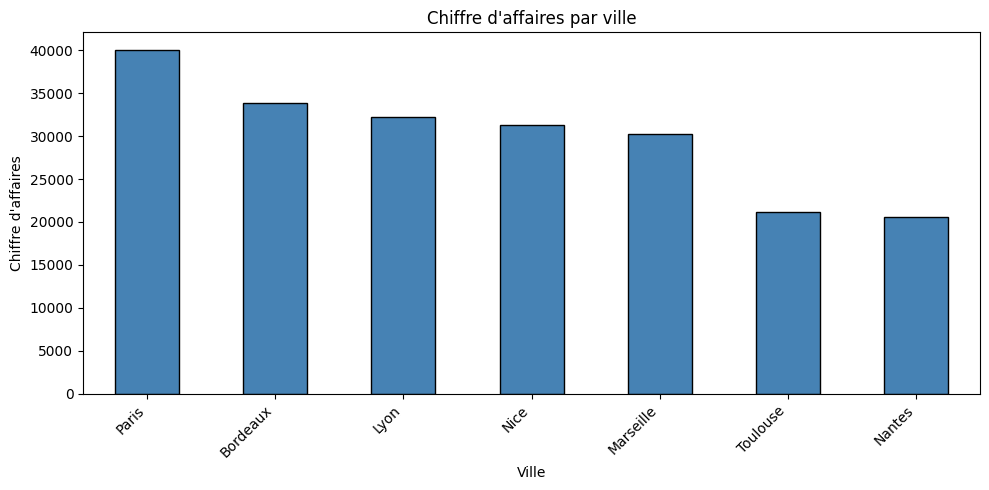

In [41]:
# code
ca_ville = df_clean.groupby('City')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ca_ville.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Chiffre d'affaires par ville")
plt.xlabel("Ville")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Réponse :**

La génération de ce graphique en barres (bar chart) permet de traduire visuellement les résultats tabulaires obtenus précédemment et facilite l'interprétation immédiate de la performance des ventes par zone géographique.

** Analyse du graphique :**

* Domination macrocéphale : *Paris* se détache nettement en première position, franchissant la barre symbolique des $40 000$ de chiffre d'affaires.

* Peloton intermédiaire homogène : On observe une forte régularité entre *Bordeaux*, *Lyon*, *Nice* et *Marseille*, dont les hauteurs de barres sont très proches, oscillant de manière stable autour des $30 000$ à $33 000$.

* Retrait structurel : Un décrochage visuel net apparaît pour *Toulouse* et *Nantes*, qui ferment la marche avec des volumes d'activité réduits de près de moitié par rapport au leader parisien.

Ce livrable visuel valide graphiquement la structure de notre chiffre d'affaires territorial et met en évidence les priorités stratégiques commerciales à donner à chaque agglomération.

## Exercice 33 : Visualisation

**Question :** Créer un graphique en barres du chiffre d’affaires par catégorie de produit.


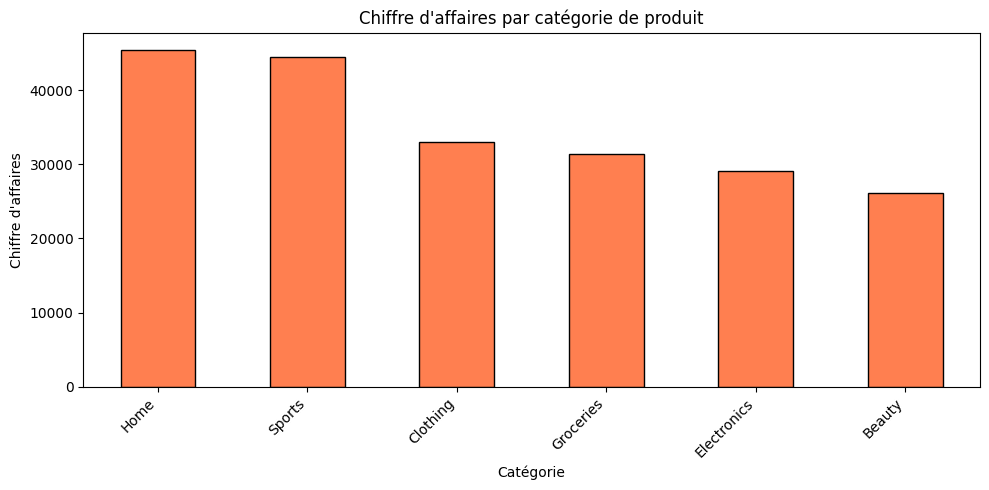

In [42]:
# code
ca_categorie = df_clean.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ca_categorie.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Chiffre d'affaires par catégorie de produit")
plt.xlabel("Catégorie")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Réponse :**

La création de ce graphique en barres permet de visualiser instantanément la hiérarchie et le poids de chaque catégorie de produits au sein de la performance commerciale globale.

**Analyse du graphique :**

* Le duo de tête : Les catégories *Home* (Maison) et *Sports* se détachent clairement comme les deux piliers majeurs de l'activité, franchissant toutes deux la barre des $44 000$ de chiffre d'affaires.

* Le segment intermédiaire : Les univers *Clothing* (Vêtements) et *Groceries* (Épicerie) forment un palier intermédiaire solide et homogène, se stabilisant juste au-dessus des $30 000$.

* Les segments secondaires : Enfin, les catégories *Electronics* (Électronique) et *Beauty* (Beauté) ferment la marche, affichant une contribution plus modeste, sous la barre des $30 000$.

Cette visualisation donne une vision claire des préférences d'achat des clients et offre une base solide pour optimiser l'allocation des budgets marketing ou la gestion des stocks par univers de produits.

## Exercice 34 : Visualisation

**Question :** Créer un histogramme de la colonne `Revenue`.

Quel est le modèle ?


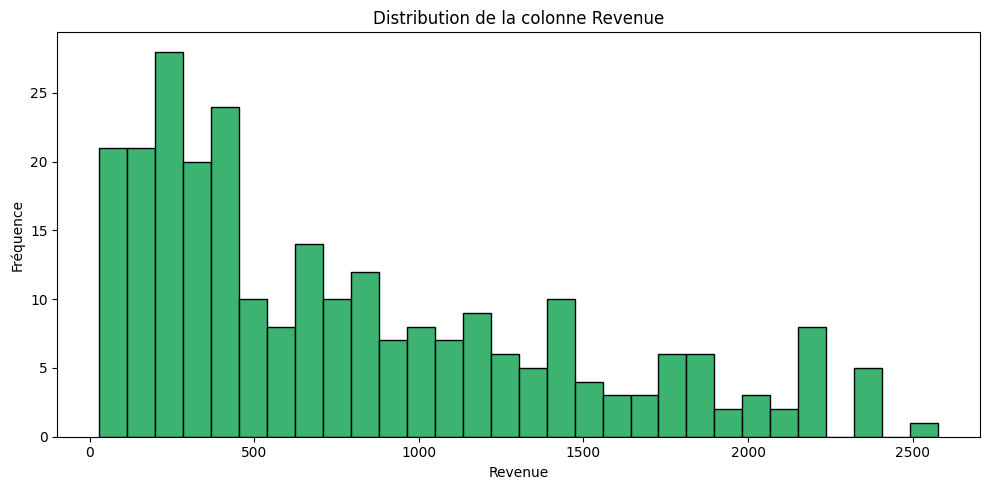

In [43]:
# code
plt.figure(figsize=(10, 5))
plt.hist(df_clean['Revenue'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title("Distribution de la colonne Revenue")
plt.xlabel("Revenue")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

**Réponse :**

La création de ce graphique en secteurs permet d'observer la répartition partitive du chiffre d'affaires global selon le type de profil client (`Customer_Type`).

** Analyse du graphique :**

* Équilibre des segments : Le volume d'activité se sépare de manière presque symétrique entre les deux catégories de clients. Les clients membres (Member) représentent la part majoritaire avec $50,6$% du chiffre d'affaires, suivis de très près par les clients normaux (Normal) qui comptent pour $49,4$%.

* Interprétation métier : Cet écart minime de $1,2$% montre que le programme de fidélité (statut Member) et le flux de clients occasionnels (statut Normal) contribuent de façon équivalente à la performance de l'entreprise.

Il pourrait être intéressant pour l'entreprise de chercher des leviers d'action pour inciter les $49,4$% de clients "Normal" à s'abonner, afin de maximiser leur valeur à long terme.


# Conclusion

En quelques lignes, résumez :

1. les principaux problèmes de qualité de données identifiés
2. les corrections réalisées
3. une ou deux conclusions business sur les ventes


**Réponse finale :**
